In [39]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import scipy.io.wavfile as wav
import scipy.signal as signal
import soundfile as sf
from IPython.display import Audio, display

print("Library berhasil di-import!")

Library berhasil di-import!


In [40]:
# Load audio dengan librosa (sr=None agar menggunakan sample rate asli)
file_path = "audio_original.wav"
y, sr = librosa.load(file_path, sr=None)

# Hitung metadata
durasi = len(y) / sr
total_sampel = len(y)
amplitude_min = np.min(y)
amplitude_max = np.max(y)

# Cetak hasil
print(f"Sample Rate (fs) : {sr} Hz")
print(f"Durasi Audio     : {durasi:.2f} detik")
print(f"Total Sampel     : {total_sampel}")
print(f"Nilai Min/Max    : {amplitude_min:.4f} / {amplitude_max:.4f}")
print("Audio:")
display(Audio(data=y, rate=sr))

Sample Rate (fs) : 48000 Hz
Durasi Audio     : 11.02 detik
Total Sampel     : 528960
Nilai Min/Max    : -0.1573 / 0.1531
Audio:


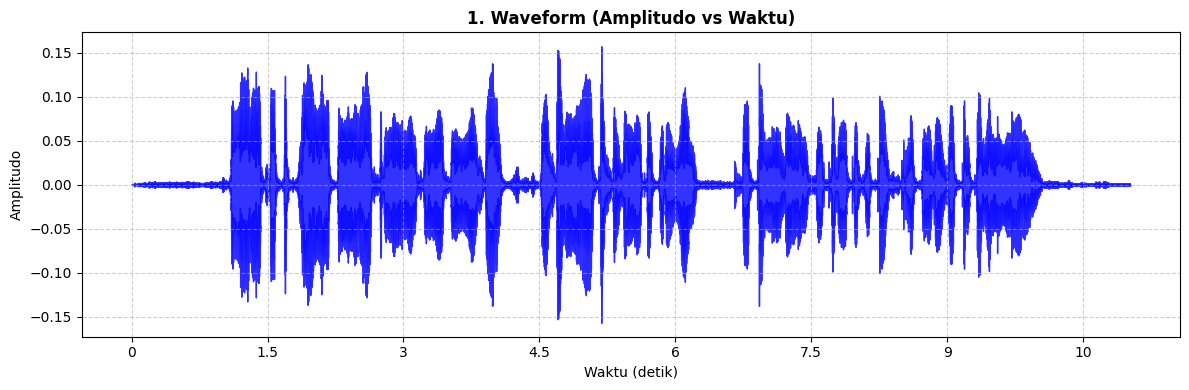

In [41]:
# Grafik Waveform
# Create figure
plt.figure(figsize=(12, 4))

# Plot waveform
librosa.display.waveshow(y, sr=sr, alpha=0.8, color='b')

plt.title('1. Waveform (Amplitudo vs Waktu)', fontsize=12, fontweight='bold')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Grafik di atas menampilkan sinyal audio pada domain waktu, sumbu X menunjukan durasi dalam detik dan sumbu Y menunjukkan nilai amplitudo sinyal. Dari grafik ini, terlihat jelas batas segmentasi antara area tuturan vokal pembacaan artikel berita yang memiliki kenaikan amplitudo signifikan pada sumbu Y dikisaran $\pm 0.15$. Pada interval jeda bicara tersebut sepanjang sumbu X seperti pada detik 0.0–1.0 dan jeda di tengah kalimat, nilai amplitudo pada sumbu Y tidak pernah menyentuh 0.00. Hal ini dikarenakan adana noise floor statis yang selalu ada selama proses perekaman

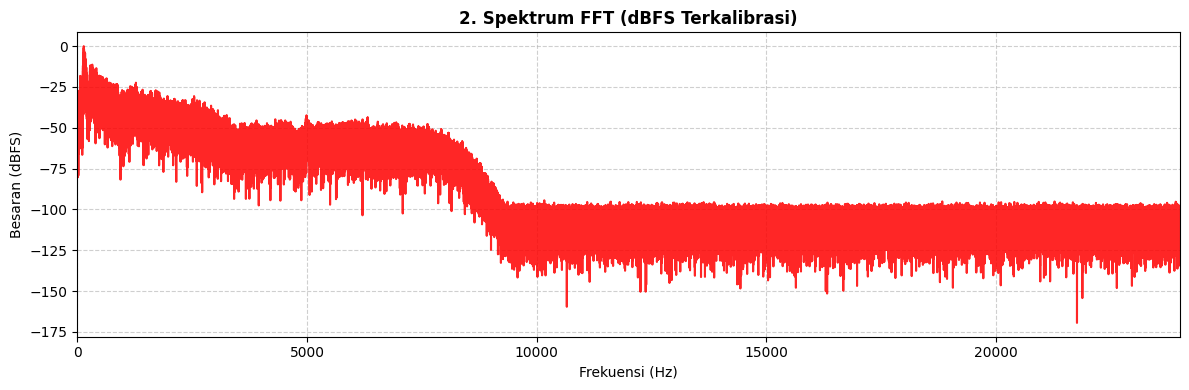

In [42]:
# Grafik Spektrum FFT
# Hitung FFT
n_fft = len(y)
fft_spectrum = np.fft.rfft(y)
freqs = np.fft.rfftfreq(n_fft, d=1/sr)

# Konversi magnitude ke dBFS
magnitude = np.abs(fft_spectrum)
# Hindari log(0) dengan menambahkan epsilon kecil
magnitude_db = 20 * np.log10(magnitude / np.max(magnitude) + 1e-12)

# Plot Spektrum FFT
plt.figure(figsize=(12, 4))
plt.plot(freqs, magnitude_db, color='r', alpha=0.85)
plt.title('2. Spektrum FFT (dBFS Terkalibrasi)', fontsize=12, fontweight='bold')
plt.xlabel('Frekuensi (Hz)')
plt.ylabel('Besaran (dBFS)')
plt.xlim(0, sr / 2)  # Nyquist Limit
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Grafik Spektrum FFT ini menunjukkan seberapa kuat setiap nada dari nada paling rendah ke nada paling tinggi pada rekaman audio. Kekuatan suara paling besar berkumpul di area nada rendah 0 - 4000Hz, ketika saya mulau membaca kekuatan bisa kuat hingga mencapai puncak paling keras mendekati 0dBFS. Kekuatan suara ini kemudian perlahan menurun hingga frekuensi 8000Hz, lalu turun ke area yang sangat pelan/hening sekitar -100dBFS hingga batas maksimum 24000Hz. Noisenya terlihat dari pola garis bergerigi merah yang rapat di area nada rendah hingga sedang.

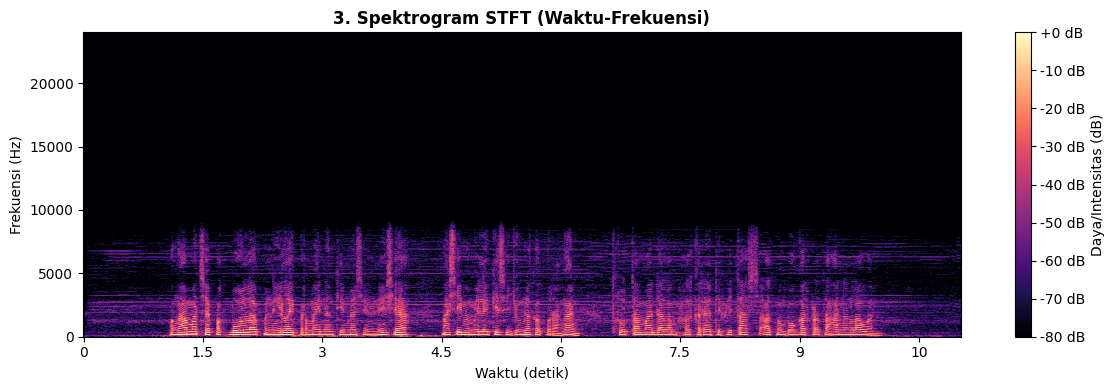

In [43]:
# Grafik Spektrogram STFT
# Hitung STFT
D = librosa.stft(y, n_fft=2048, hop_length=512)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

# Plot Spektrogram STFT
plt.figure(figsize=(12, 4))
librosa.display.specshow(S_db, sr=sr, hop_length=512, x_axis='time', y_axis='hz', cmap='magma')
plt.colorbar(format='%+2.0f dB', label='Daya/Intensitas (dB)')
plt.title('3. Spektrogram STFT (Waktu-Frekuensi)', fontsize=12, fontweight='bold')
plt.xlabel('Waktu (detik)')
plt.ylabel('Frekuensi (Hz)')
plt.tight_layout()
plt.show()

Spektrogram STFT menunjukan suara dan noise secara bersamaan. Suara saya terlihat sebagai pola garis-garis vertikal berwarna terang di rentang 0–4000 Hz yang muncul ketika mulai berbicara. Sementara itu, noisenya terlihat sebagai horizontal tipis yang muncul terus-menerus dari detik pertama sampai akhir di rentang 0–8000 Hz. Karena pola garis noise ini bentuknya rata dan tidak berubah-ubah sepanjang waktu, ini menandakan noise-nya bersifat konstan.

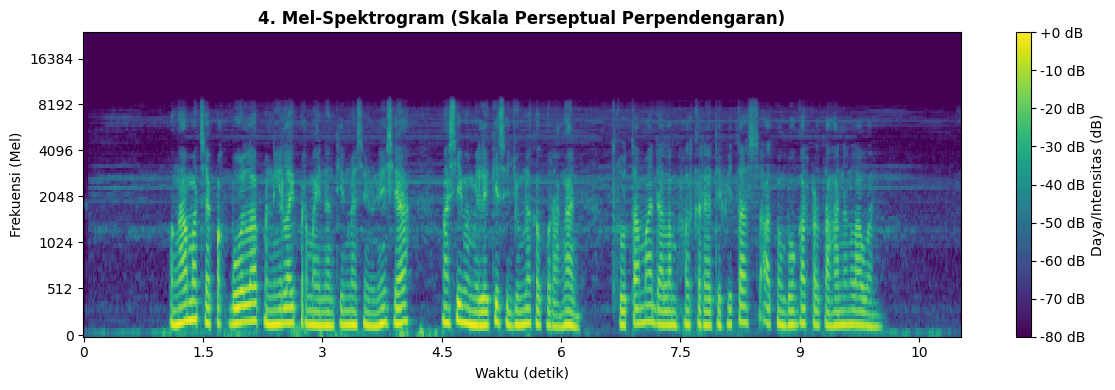

In [44]:
# Grafik Mel-Spektrogram
# Hitung Mel-Spektrogram
S_mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
S_mel_db = librosa.power_to_db(S_mel, ref=np.max)

# Plot Mel-Spektrogram
plt.figure(figsize=(12, 4))
librosa.display.specshow(S_mel_db, sr=sr, hop_length=512, x_axis='time', y_axis='mel', cmap='viridis')
plt.colorbar(format='%+2.0f dB', label='Daya/Intensitas (dB)')
plt.title('4. Mel-Spektrogram (Skala Perseptual Perpendengaran)', fontsize=12, fontweight='bold')
plt.xlabel('Waktu (detik)')
plt.ylabel('Frekuensi (Mel)')
plt.tight_layout()
plt.show()

Grafik Mel-Spektrogram. Terlihat seperti ada 3 kelompok gelombang utama  yang diselingi oleh area ungu gelap. Ini menandakan saya  sedang mengucapkan beberapa kata atau kalimat di detik ke-1 hingga 4, detik ke-4.5 hingga 6, dan detik ke-7 hingga 10. Noise yang  muncul terus-menerus tanpa henti dari detik ke-0 hingga detik ke-10 bahkan di saat sedang diam ditandai dengan warna biru menyebar, menunjukkan adanya suara mengganggu dengan intensitas sedang.

In [45]:
# Tentukan target sample rate (5000 Hz)
sr_target = 5000

# Hitung faktor decimation M
M = int(sr / sr_target)
print(f"Menggunakan faktor decimation M = {M} (Sample rate target: {sr/M:.0f} Hz)")

# --- Skenario A: Naive Decimation (Tanpa Anti-Aliasing Filter) ---
y_naive = y[::M]
sr_naive = sr // M

# --- Skenario B: Clean Resampling (Dengan Anti-Aliasing Filter) ---
y_clean = librosa.resample(y, orig_sr=sr, target_sr=sr_target)
sr_clean = sr_target

# Simpan kedua file WAV ke folder (sesuai ketentuan struktur repositori)
import soundfile as sf

sf.write('audio_downsampled_naive.wav', y_naive, sr_naive)
sf.write('audio_downsampled_clean.wav', y_clean, sr_clean)

print("File audio hasil downsampling berhasil dibuat & disimpan!\n")

# --- Display Pemutar Audio Interaktif ---
print("1. Audio Skenario A (Naive Decimation - Terjadi Aliasing):")
display(Audio(data=y_naive, rate=sr_naive))

print("2. Audio Skenario B (Clean Resampling - Dengan Anti-Aliasing):")
display(Audio(data=y_clean, rate=sr_clean))

Menggunakan faktor decimation M = 9 (Sample rate target: 5333 Hz)
File audio hasil downsampling berhasil dibuat & disimpan!

1. Audio Skenario A (Naive Decimation - Terjadi Aliasing):


2. Audio Skenario B (Clean Resampling - Dengan Anti-Aliasing):


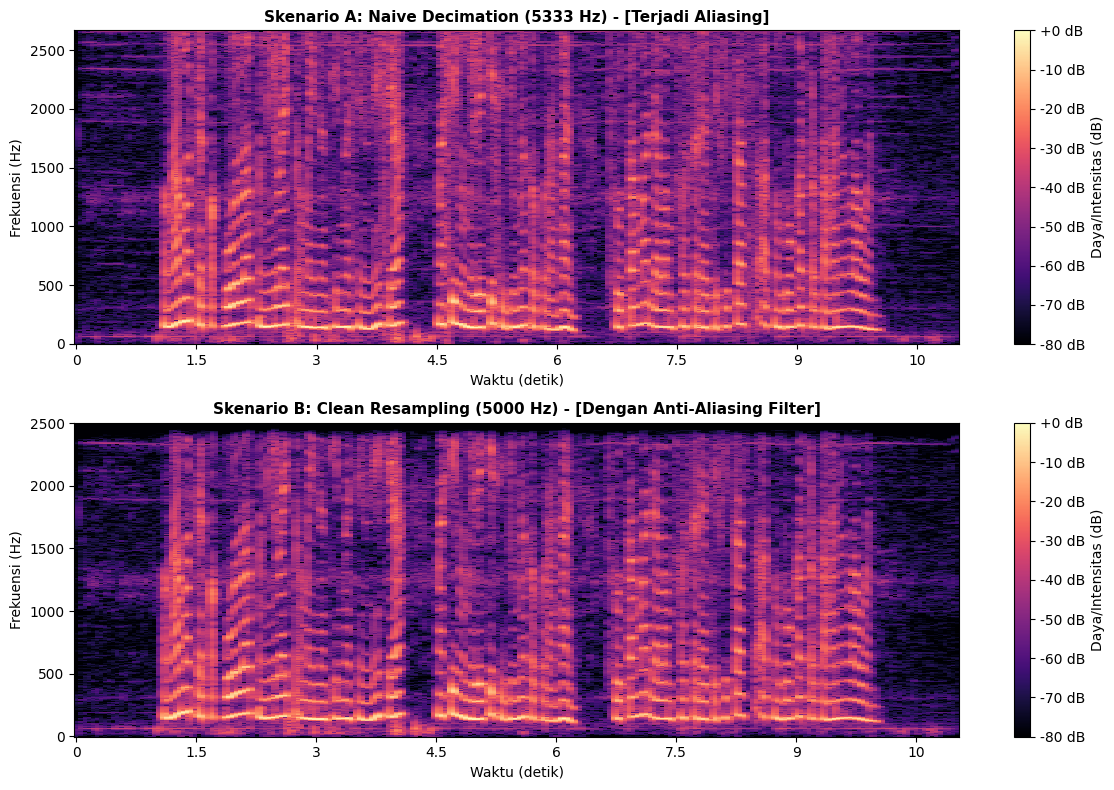

In [46]:
# 1. Hitung Resampling / Downsampling dengan target 5000 Hz
sr_target = 5000
M = int(sr / sr_target)

# Skenario A: Naive Decimation (Tanpa Anti-Aliasing Filter)
y_naive = y[::M]
sr_naive = sr // M

# Skenario B: Clean Resampling (Dengan Anti-Aliasing Filter)
y_clean = librosa.resample(y, orig_sr=sr, target_sr=sr_target)
sr_clean = sr_target

# Simpan kedua file WAV hasil downsampling ke folder
sf.write('audio_downsampled_naive.wav', y_naive, sr_naive)
sf.write('audio_downsampled_clean.wav', y_clean, sr_clean)

# 2. Hitung STFT Spektrogram untuk Kedua Sinyal
D_naive = librosa.stft(y_naive, n_fft=1024, hop_length=256)
S_db_naive = librosa.amplitude_to_db(np.abs(D_naive), ref=np.max)

D_clean = librosa.stft(y_clean, n_fft=1024, hop_length=256)
S_db_clean = librosa.amplitude_to_db(np.abs(D_clean), ref=np.max)

# 3. Plot Komparasi Spektrogram Vertikal (Atas - Bawah)
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# Grafik Atas: Skenario A (Naive Decimation)
img1 = librosa.display.specshow(S_db_naive, sr=sr_naive, hop_length=256, x_axis='time', y_axis='hz', ax=ax[0], cmap='magma')
ax[0].set_title(f'Skenario A: Naive Decimation ({sr_naive} Hz) - [Terjadi Aliasing]', fontsize=11, fontweight='bold')
ax[0].set_xlabel('Waktu (detik)')
ax[0].set_ylabel('Frekuensi (Hz)')
fig.colorbar(img1, ax=ax[0], format='%+2.0f dB', label='Daya/Intensitas (dB)')

# Grafik Bawah: Skenario B (Clean Resampling)
img2 = librosa.display.specshow(S_db_clean, sr=sr_clean, hop_length=256, x_axis='time', y_axis='hz', ax=ax[1], cmap='magma')
ax[1].set_title(f'Skenario B: Clean Resampling ({sr_clean} Hz) - [Dengan Anti-Aliasing Filter]', fontsize=11, fontweight='bold')
ax[1].set_xlabel('Waktu (detik)')
ax[1].set_ylabel('Frekuensi (Hz)')
fig.colorbar(img2, ax=ax[1], format='%+2.0f dB', label='Daya/Intensitas (dB)')

plt.tight_layout()
plt.show()

Skenario A/Grafik Atas, Terjadi kecacatan suara yang disebut aliasing karena proses penurunan ukuran file audio dilakukan secara asal potong tanpa filter. Gangguan ini terlihat sangat jelas dari adanya pola garis-garis dan bayangan tambahan di area nada tinggi 2000 - 2600Hz, serta munculnya noise oada bagian-bagian yang seharusnya hening seperti di detik 0–1 dan 4.5–5. Hal ini terjadi karena nada-nada tinggi yang tidak dibuang malah "memantul balik" dan berubah menjadi suara palsu yang merusak kualitas rekaman.   

Skenario B/Grafik Bawah, Hasil rekaman terlihat jauh lebih bersih karena menggunakan anti-aliasing filter sebelum ukurannya diperkecil. Penyaring ini secara otomatis membuang seluruh nada tinggi yang melebihi batas 2500Hz, sehingga bagian atas grafik terpotong dengan rapi tanpa meninggalkan bayangan sinyal palsu . sehingga, suara membaca artikel di area bawah 0 - 2000Hz tetap terdengan lumayan jernih sesuai dengan aslinya.